# Fast Interval Search versus Search with Full Propositionalisation

As test cases we use random normal data with positively and negatively correlated blocks of variables.
For the weights we consider two cases:

1. independent normally distributed weights $w \sim N(0, 1)$
2. adversarial examples where the best solutions is given by the last variable, $w \sim N(x_{2k}, 1)$

In [79]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import numpy as np
from testdata import diblock_mvn_sample

seeds = 5
ns = [50, 100, 200]
ks = [1, 2, 3, 4, 5]

xs = [[[diblock_mvn_sample(n, k, seed=s, rho_between=0, rho_within=0) for n in ns] for k in ks] for s in range(seeds)]
ws_independent = [[[np.random.default_rng(seed=s).normal(0, 1, size=n) for n in ns] for k in ks] for s in range(seeds)]
ws_adversarial = [[[np.random.default_rng(seed=s).normal(xs[s][k_idx][n_idx][:, 2*ks[k_idx]-1], 0.1, size=ns[n_idx]) for n_idx in range(len(ns))] for k_idx in range(len(ks))] for s in range(seeds)]
xs[0][4][2].shape, ws_independent[0][4][2].shape, ws_adversarial[0][4][2].shape

/Users/marioboley/Documents/GitHub/optikon/testdata.py:39: RuntimeWarning: divide by zero encountered in matmul
  return rng.multivariate_normal(np.zeros(size), cov, size=n)
/Users/marioboley/Documents/GitHub/optikon/testdata.py:39: RuntimeWarning: overflow encountered in matmul
  return rng.multivariate_normal(np.zeros(size), cov, size=n)
/Users/marioboley/Documents/GitHub/optikon/testdata.py:39: RuntimeWarning: invalid value encountered in matmul
  return rng.multivariate_normal(np.zeros(size), cov, size=n)


((200, 10), (200,), (200,))

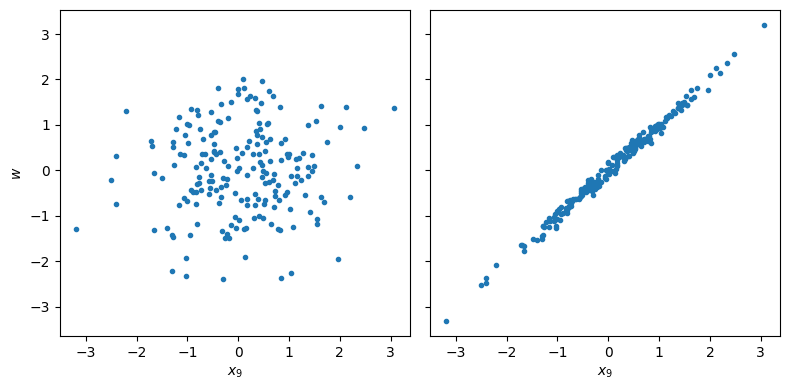

In [80]:
from matplotlib import pyplot as plt

_, ax = plt.subplots(1, 2, sharey=True, tight_layout=True, figsize=(8, 4))
ax[0].scatter(xs[0][4][2][:, 9], ws_independent[0][4][2], marker='.')
ax[1].scatter(xs[0][4][2][:, 9], ws_adversarial[0][4][2], marker='.')
ax[0].set_ylabel('$w$')
ax[0].set_xlabel('$x_9$')
ax[1].set_xlabel('$x_9$')
plt.show()

In [81]:
from optikon import max_weighted_support_fips, full_propositionalization, max_weighted_support_bb

props = full_propositionalization(xs[0][0][0])
max_weighted_support_bb(xs[0][0][0], ws_independent[0][0][0], props, max_depth=2)
best, value, stats = max_weighted_support_fips(xs[0][0][0], ws_independent[0][0][0], max_depth=2)
best.as_conj_str(), value, stats

('x1 <= 0.250 & x2 >= -1.091',
 7.277642158266015,
 DictType[unicode_type,int64]<iv=None>({nodes_created: 1697, nodes_enqueued: 1621}))

## Independent

In [ ]:
from optikon import max_weighted_support_bb, max_weighted_support_fips, full_propositionalization
import time

ds = np.array([2, 3, 4, 5, 6]) # depth limits
times_fips_independent = np.empty(shape=(seeds, len(ks), len(ns), len(ds)))
values_fips_independent = np.empty(shape=(seeds, len(ks), len(ns), len(ds)))
created_fips_independent = np.empty(shape=(seeds, len(ks), len(ns), len(ds)))

for s in range(seeds):
    print('seed', s)
    for k_idx, k in enumerate(ks):
        print('k:', k, end=' ', flush=True)
        print('d:', end=' ', flush=True)
        for d_idx, d in enumerate(ds):
            print(d, flush=True, end='...')
            start = time.perf_counter()
            best, value, stats = max_weighted_support_fips(xs[s][k_idx][0], ws_independent[s][k_idx][0], max_depth=d)
            end = time.perf_counter()
            times_fips_independent[s, k_idx, 0, d_idx] = end - start
            values_fips_independent[s, k_idx, 0, d_idx] = value
            created_fips_independent[s, k_idx, 0, d_idx] = stats['nodes_created']
        print(flush=True)

seed 0
k: 1 d: 2...3...4...5...6...
k: 2 d: 2...3...4...5...6...
k: 3 d: 2...3...4...5...6...
k: 4 d: 2...3...4...5...6...
k: 5 d: 2...3...4...5...6...
seed 1
k: 1 d: 2...3...4...5...6...
k: 2 d: 2...3...4...5...6...
k: 3 d: 2...3...4...5...6...
k: 4 d: 2...3...4...5...6...
k: 5 d: 2...3...4...5...6...
seed 2
k: 1 d: 2...3...4...5...6...
k: 2 d: 2...3...4...5...6...
k: 3 d: 2...3...4...5...6...
k: 4 d: 2...3...4...5...6...
k: 5 d: 2...3...4...5...6...
seed 3
k: 1 d: 2...3...4...5...6...
k: 2 d: 2...3...4...5...6...
k: 3 d: 2...3...4...5...6...
k: 4 d: 2...3...4...5...6...
k: 5 d: 2...3...4...5...6...
seed 4
k: 1 d: 2...3...4...5...6...
k: 2 d: 2...3...4...5...6...
k: 3 d: 2...3...4...5...6...
k: 4 d: 2...3...4...5...6...
k: 5 d: 2...3...4...5...6...


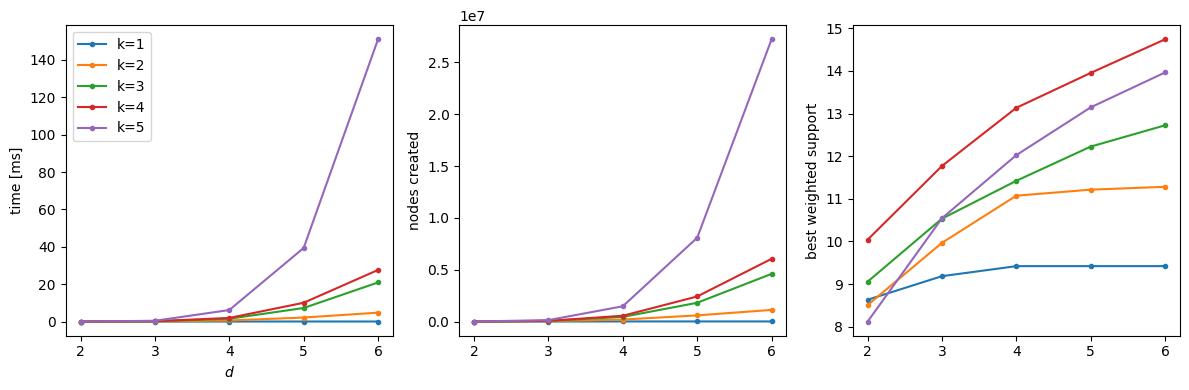

In [84]:
_, axs = plt.subplots(1, 3, tight_layout=True, figsize=(12, 4))

for k_idx, k in enumerate(ks):
    axs[0].plot(ds, times_fips_independent[:, k_idx, 0, :].mean(axis=0), label=f'k={k}', marker='.')

for k_idx, k in enumerate(ds):
    axs[1].plot(ds, created_fips_independent[:, k_idx, 0, :].mean(axis=0), label=f'{k}', marker='.')

for k_idx, k in enumerate(ds):
    axs[2].plot(ds, values_fips_independent[:, k_idx, 0, :].mean(axis=0), label=f'{k}', marker='.')

axs[0].legend()
axs[0].set_ylabel('time [ms]')
axs[0].set_xlabel('$d$')
axs[1].set_ylabel('nodes created')
axs[2].set_ylabel('best weighted support')
# plt.margins(x=0)
plt.show()

## Adversarial Weights

In [ ]:
times_fips_adversarial = np.empty(shape=(len(ks), len(ns), len(ds)))
values_fips_adversarial = np.empty(shape=(len(ks), len(ns), len(ds)))
created_fips_adversarial = np.empty(shape=(len(ks), len(ns), len(ds)))

for k_idx, k in enumerate(ks):
    print('k:', k, flush=True)
    print('d:', end=' ', flush=True)
    for d_idx, d in enumerate(ds):
        print(d, flush=True, end='...')
        start = time.perf_counter()
        best, value, stats = max_weighted_support_fips(xs[k_idx][0], ws_adversarial[k_idx][0], max_depth=d)
        end = time.perf_counter()
        times_fips_adversarial[k_idx, 0, d_idx] = end - start
        values_fips_adversarial[k_idx, 0, d_idx] = value
        created_fips_adversarial[k_idx, 0, d_idx] = stats['nodes_created']
    print(flush=True)

k: 1
d: 2...3...4...5...6...
k: 2
d: 2...3...4...5...6...
k: 3
d: 2...3...4...5...6...
k: 4
d: 2...3...4...5...6...
k: 5
d: 2...3...4...5...6...


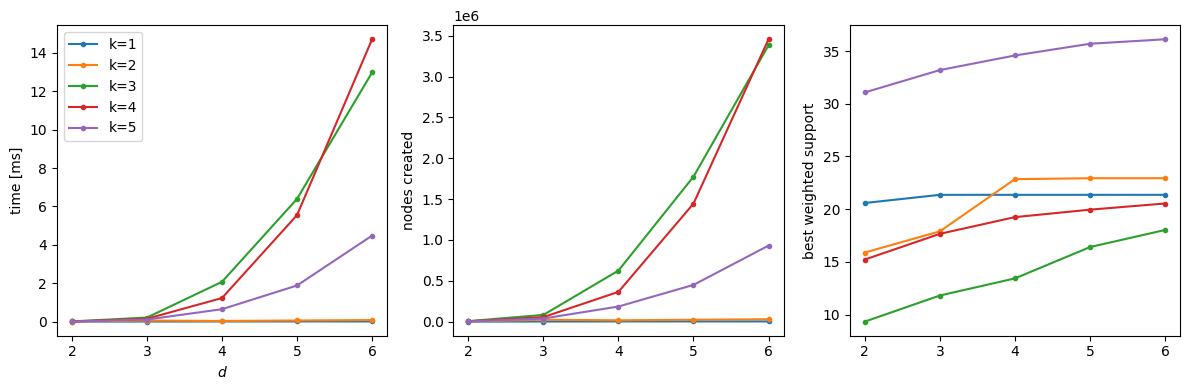

In [71]:
_, axs = plt.subplots(1, 3, tight_layout=True, figsize=(12, 4))

for k_idx, k in enumerate(ks):
    axs[0].plot(ds, times_fips_adversarial[k_idx, 0, :], label=f'k={k}', marker='.')

for k_idx, k in enumerate(ds):
    axs[1].plot(ds, created_fips_adversarial[k_idx, 0, :], label=f'{k}', marker='.')

for k_idx, k in enumerate(ds):
    axs[2].plot(ds, values_fips_adversarial[k_idx, 0, :], label=f'{k}', marker='.')

axs[0].legend()
axs[0].set_ylabel('time [ms]')
axs[0].set_xlabel('$d$')
axs[1].set_ylabel('nodes created')
axs[2].set_ylabel('best weighted support')
# plt.margins(x=0)
plt.show()

In [72]:
times_prop_adversarial = np.empty(shape=(len(ks), len(ns), len(ds)))
values_prop_adversarial = np.empty(shape=(len(ks), len(ns), len(ds)))
created_prop_adversarial = np.empty(shape=(len(ks), len(ns), len(ds)))

for k_idx, k in enumerate(ks):
    print('k:', k, flush=True)
    print('d:', end=' ', flush=True)
    for d_idx, d in enumerate(ds):
        print(d, flush=True, end='...')
        props = full_propositionalization(xs[k_idx][0])
        start = time.perf_counter()
        best, value, stats = max_weighted_support_bb(xs[k_idx][0], ws_adversarial[k_idx][0], props, max_depth=d)
        end = time.perf_counter()
        times_prop_adversarial[k_idx, 0, d_idx] = end - start
        values_prop_adversarial[k_idx, 0, d_idx] = value
        created_prop_adversarial[k_idx, 0, d_idx] = stats['nodes_created']
    print(flush=True)

k: 1
d: 2...3...4...5...6...
k: 2
d: 2...3...4...5...6...
k: 3
d: 2...3...4...5...6...
k: 4
d: 2...3...4...5...6...
k: 5
d: 2...3...4...5...6...


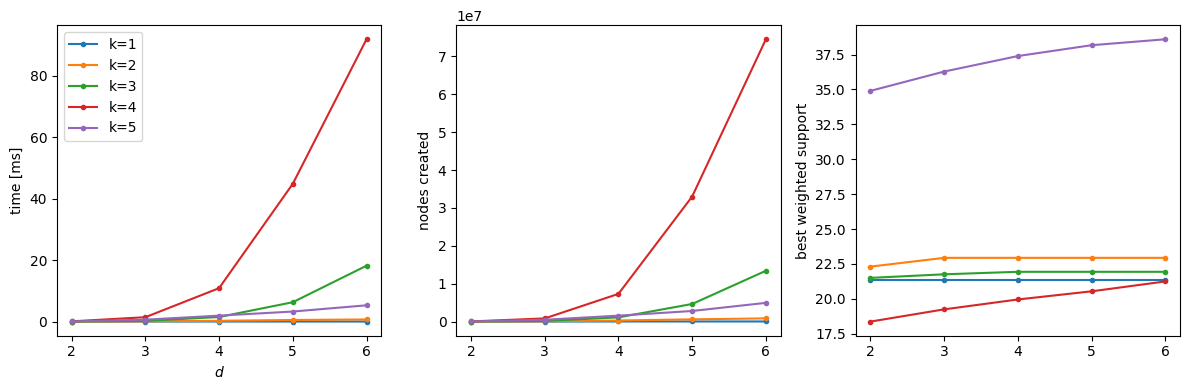

In [73]:
_, axs = plt.subplots(1, 3, tight_layout=True, figsize=(12, 4))

for k_idx, k in enumerate(ks):
    axs[0].plot(ds, times_prop_adversarial[k_idx, 0, :], label=f'k={k}', marker='.')

for k_idx, k in enumerate(ds):
    axs[1].plot(ds, created_prop_adversarial[k_idx, 0, :], label=f'{k}', marker='.')

for k_idx, k in enumerate(ds):
    axs[2].plot(ds, values_prop_adversarial[k_idx, 0, :], label=f'{k}', marker='.')

axs[0].legend()
axs[0].set_ylabel('time [ms]')
axs[0].set_xlabel('$d$')
axs[1].set_ylabel('nodes created')
axs[2].set_ylabel('best weighted support')
# plt.margins(x=0)
plt.show()